## Plot performance RUL predictions (per metric)

Reads the per-metric per-repetition CSVs written by `5r-pf_performance_rep.ipynb`
(one folder per metric under `net_arg{ARGS_ID}`) and draws a static RUL picture per
performance metric and unit. **No particle filter is run here**, it only loads data.

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

from experiment_config import dataset_path, pfnet_paths
from src.helpers.visualization import plot_rul_from_dataframe

## Configuration

In [14]:
DATA_NAME = "DS03"
ARGS_ID = 0

perform_names = ["T48", "SmFan", "SmLPC", "SmHPC"]  # metrics to plot


## Import test data

In [15]:
ESTIMATION_DIR = dataset_path(DATA_NAME, field="estimation")
PFNET_ARGS_DIR, _ = pfnet_paths(ARGS_ID, DATA_NAME)

hi_df = pd.read_csv(ESTIMATION_DIR / "data_test.csv")
test_units = hi_df["unit"].astype(int).unique().tolist()
onsets = {
    u: hi_df[(hi_df["unit"] == u) & (hi_df["hs"] == 0)]["cycle"].values[0]
    for u in test_units
}
test_units

[10, 11, 12, 13, 14, 15]

## Load performance predictions

In [16]:
# per-rep files for the selected metrics: net_arg{ARGS_ID}/{metric}/perform_test_r*.csv
rep_files = sorted(
    f
    for name in perform_names
    for f in (PFNET_ARGS_DIR / name).glob("perform_test_r*.csv")
)
df_preds = pd.concat((pd.read_csv(f) for f in rep_files), ignore_index=True)
n_reps = int(df_preds["rep"].nunique())
print(f"loaded {len(rep_files)} files ({n_reps} reps) | metrics: {perform_names}")


loaded 40 files (10 reps) | metrics: ['T48', 'SmFan', 'SmLPC', 'SmHPC']


## Per-repetition RUL predictions

/tmp/ipykernel_3225503/357699518.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 8))


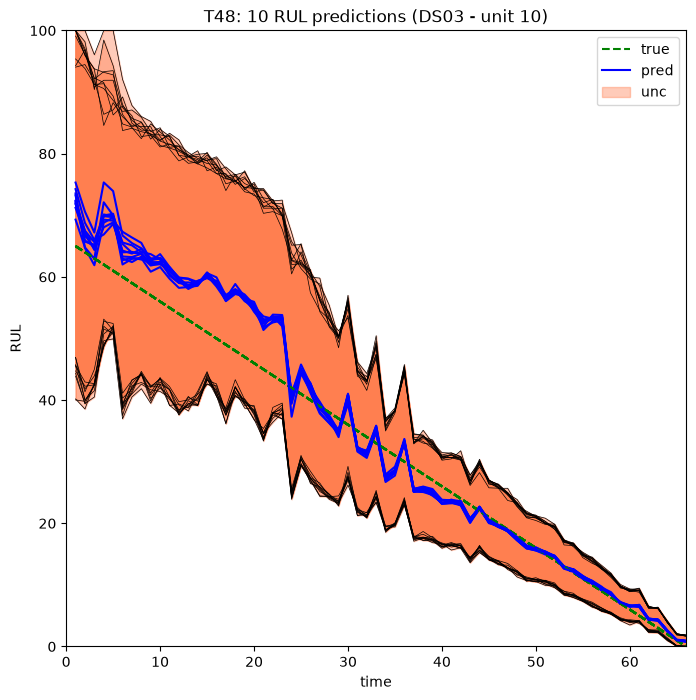

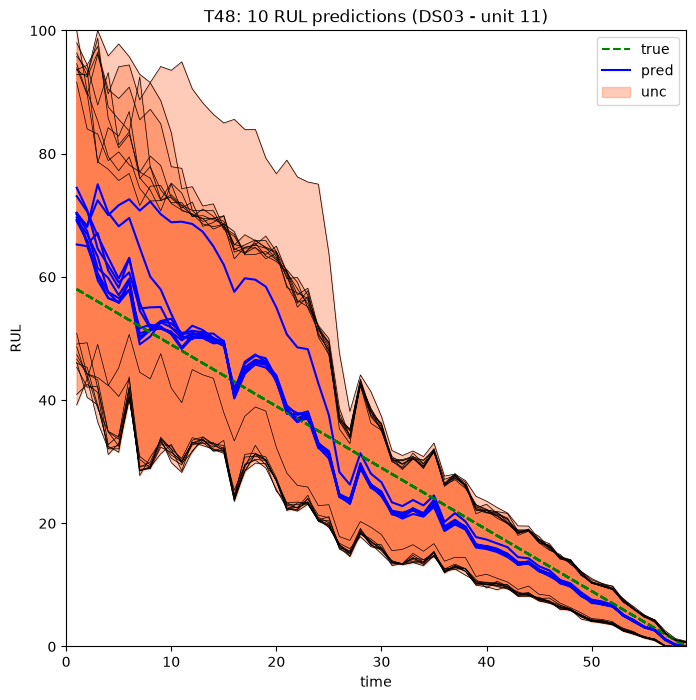

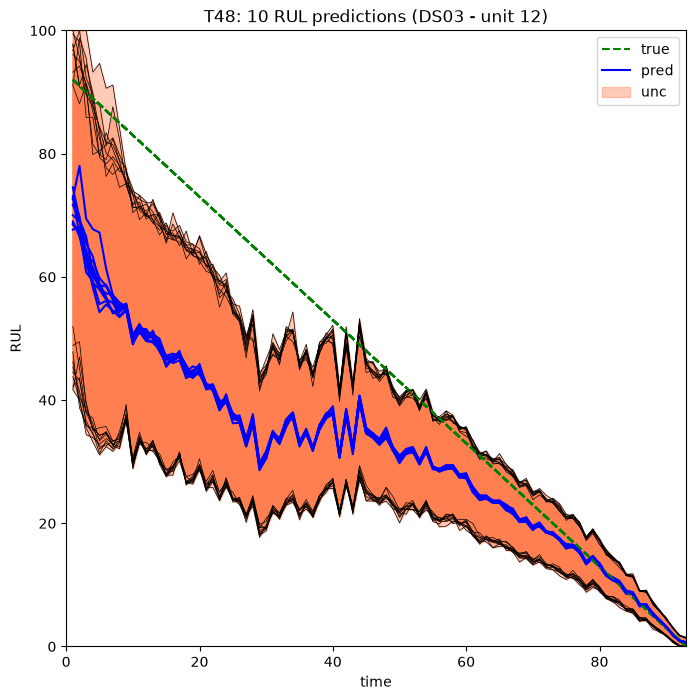

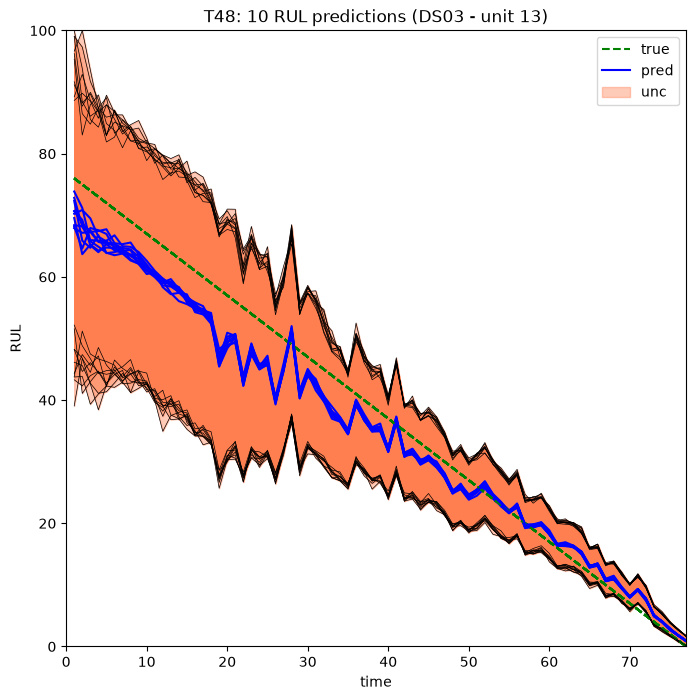

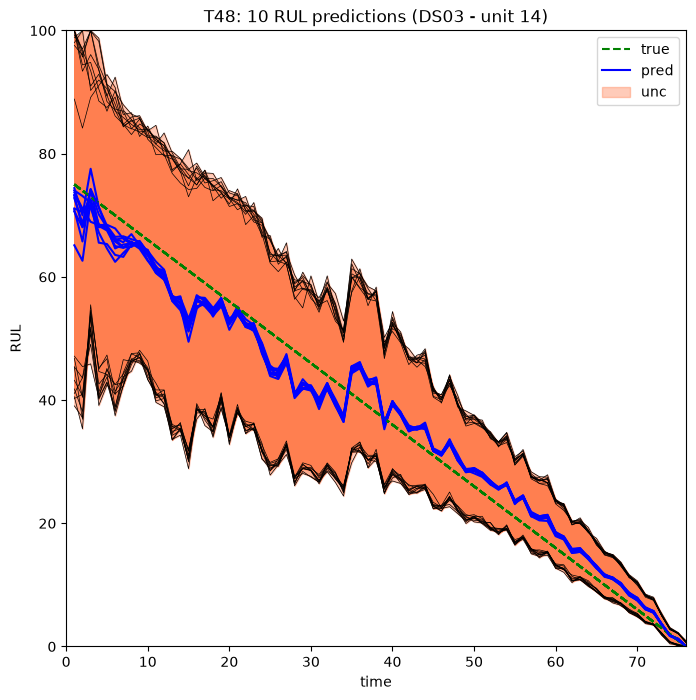

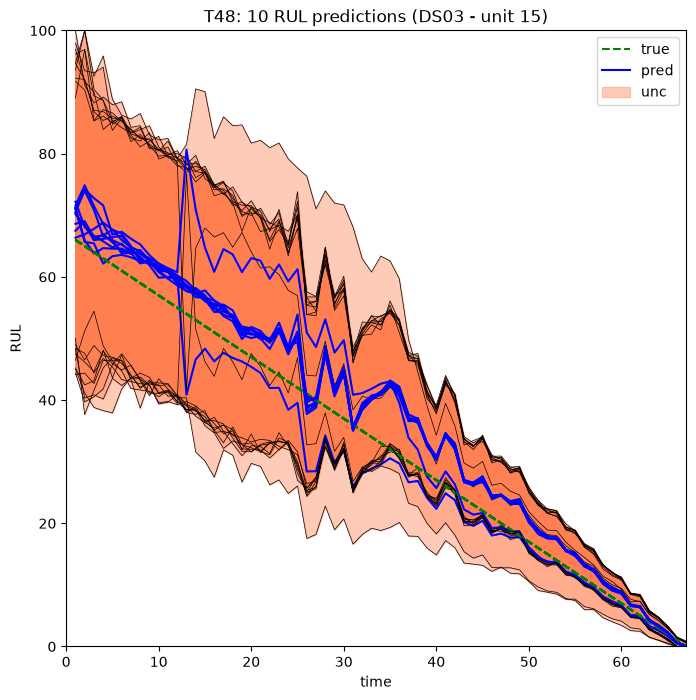

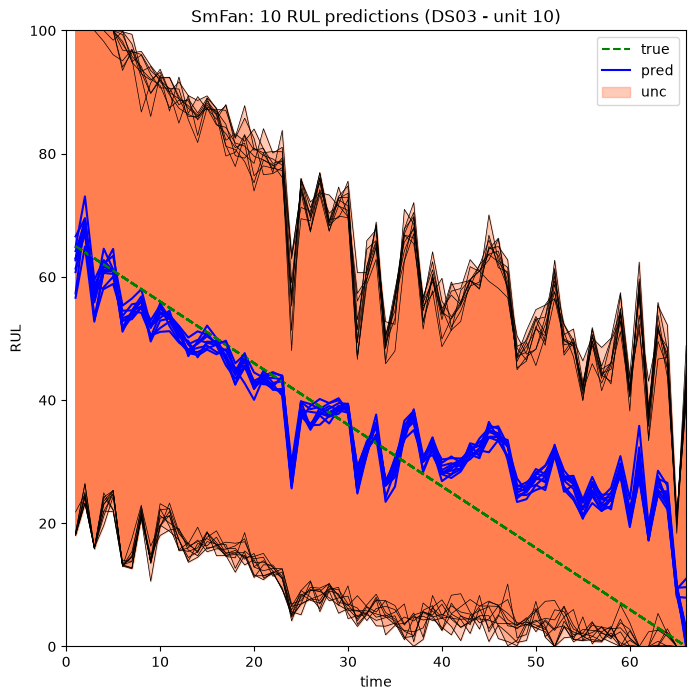

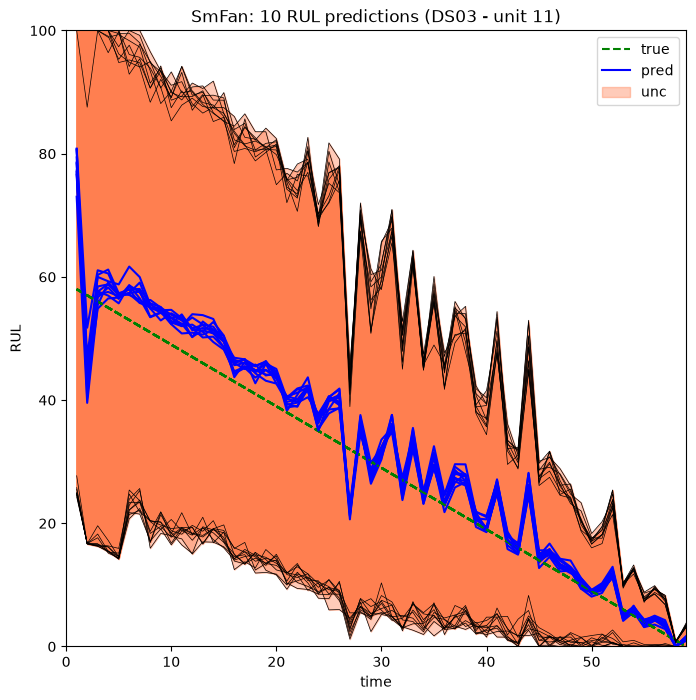

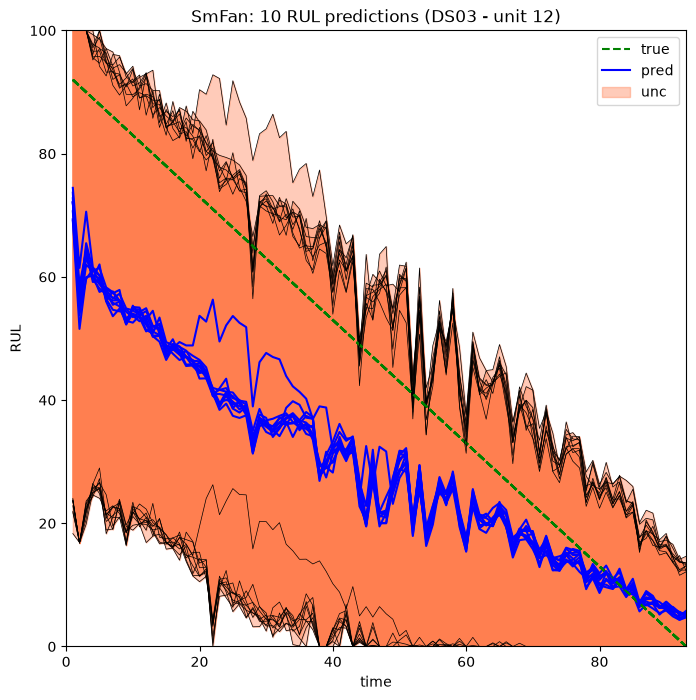

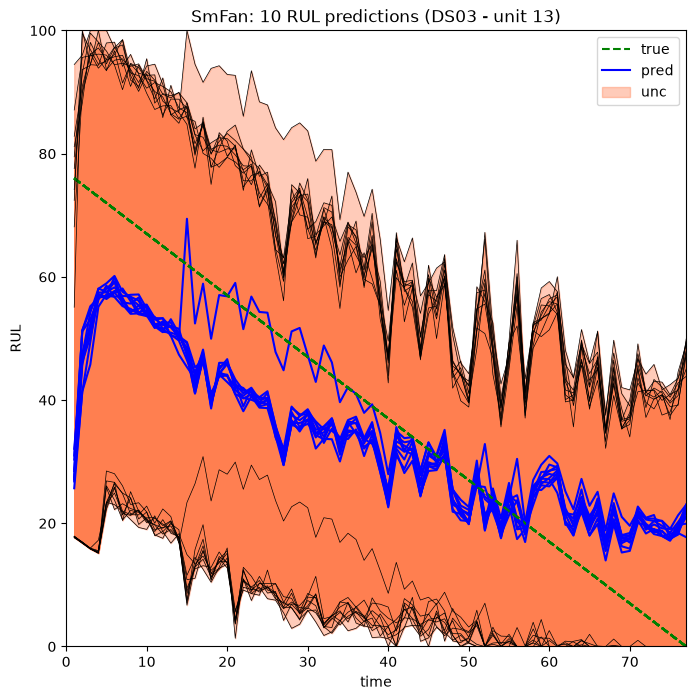

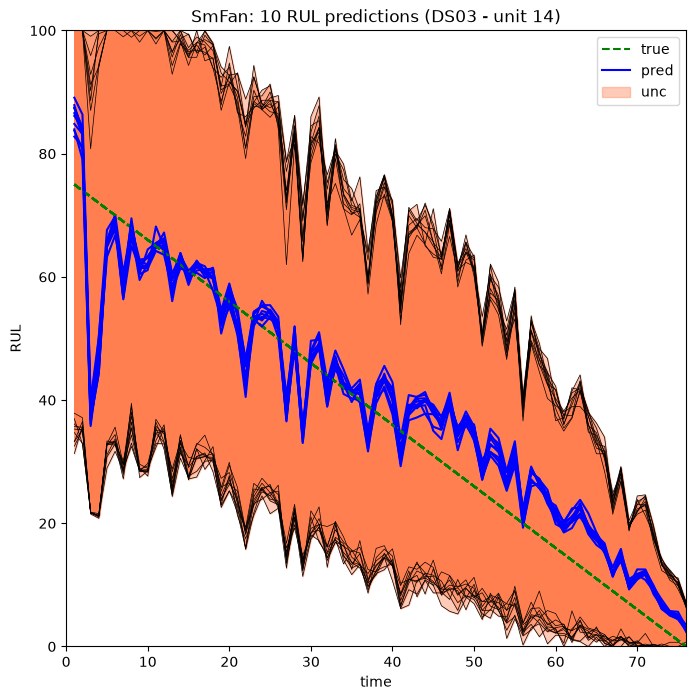

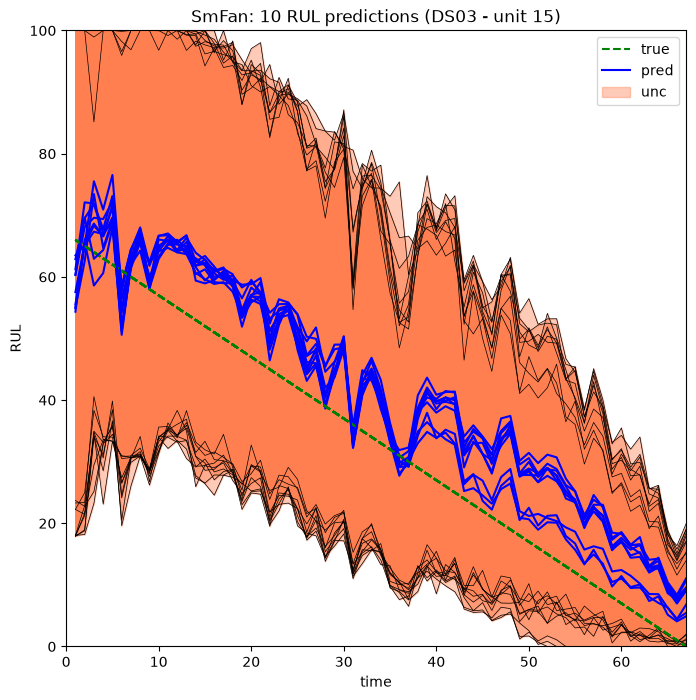

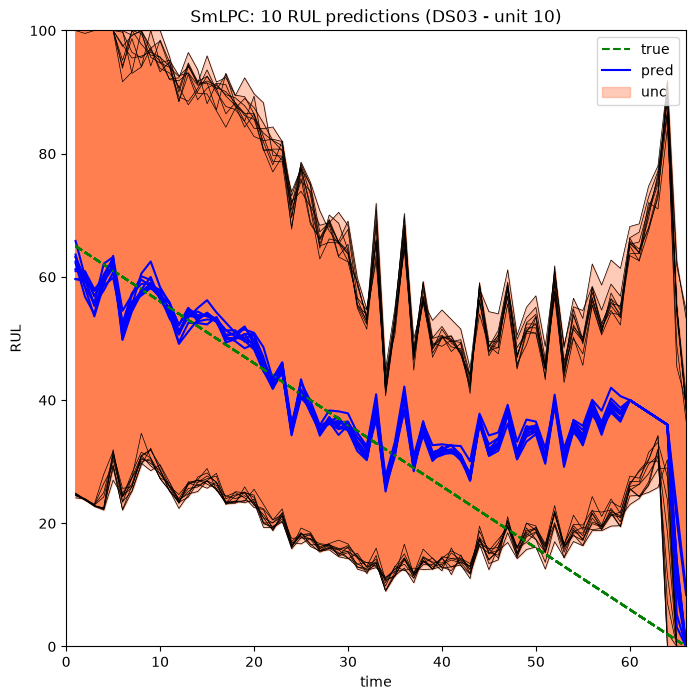

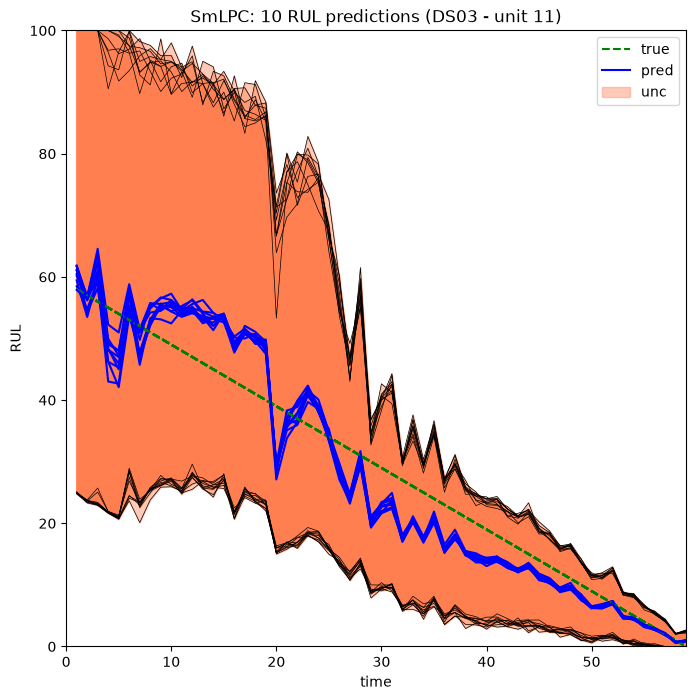

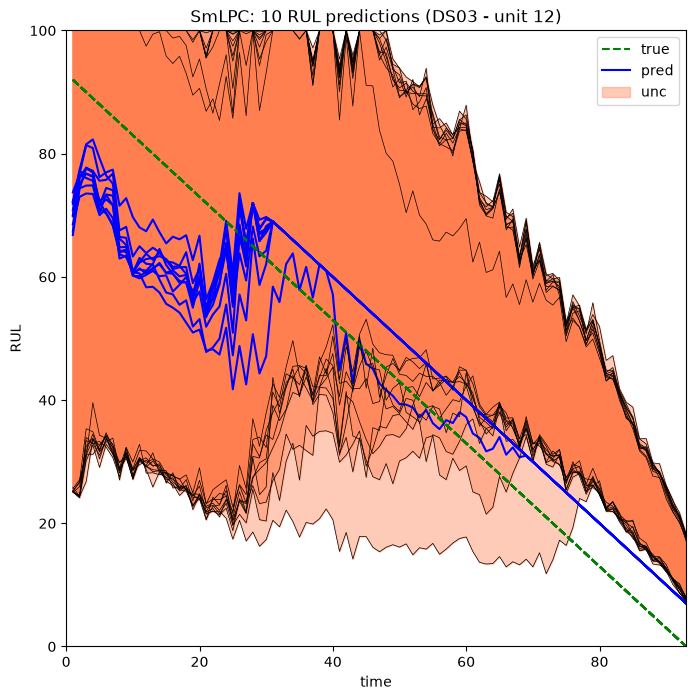

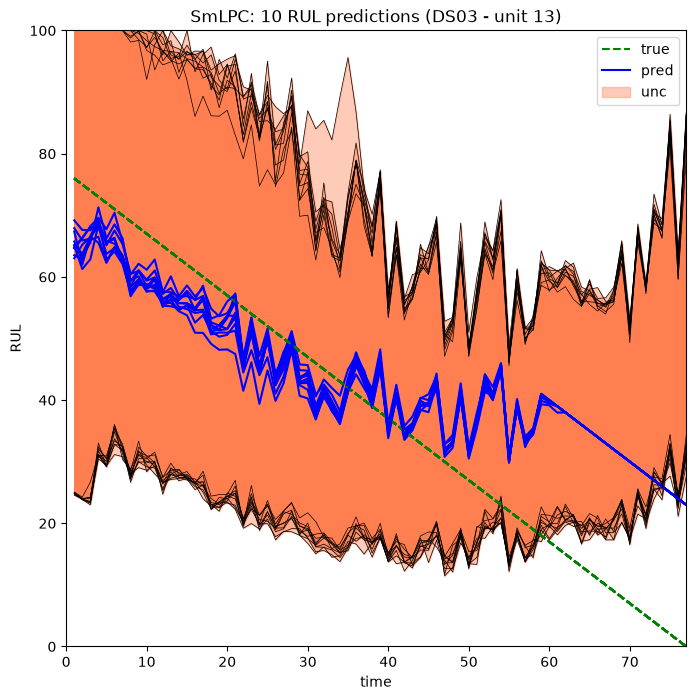

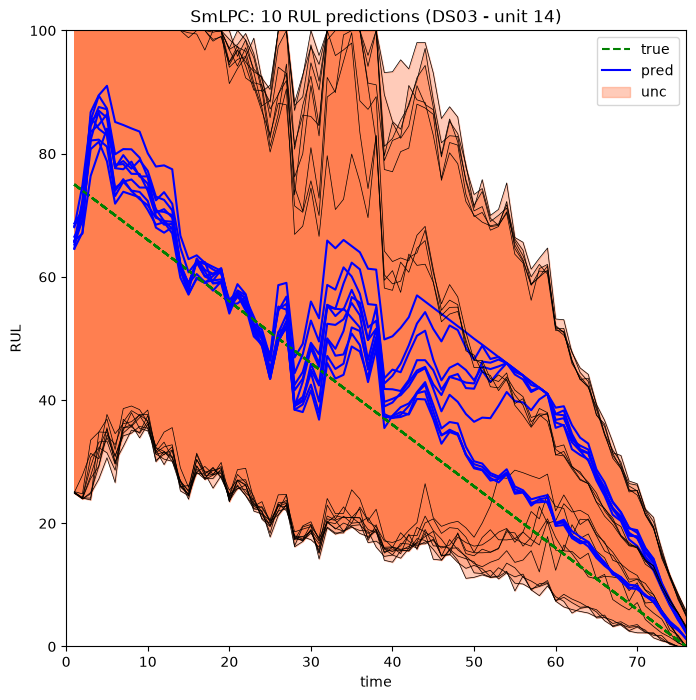

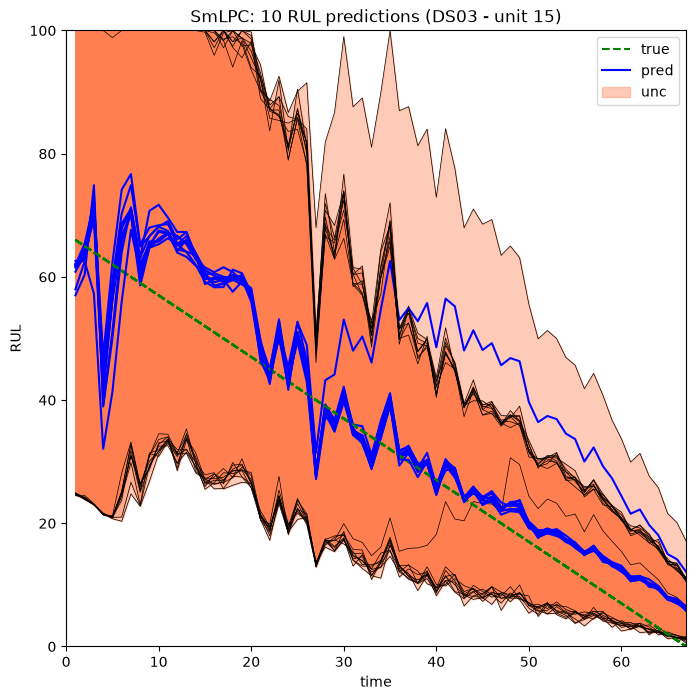

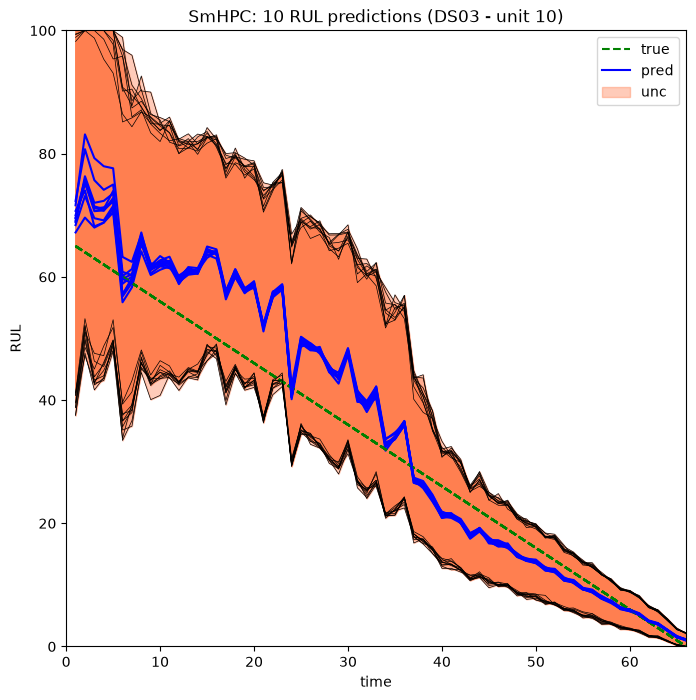

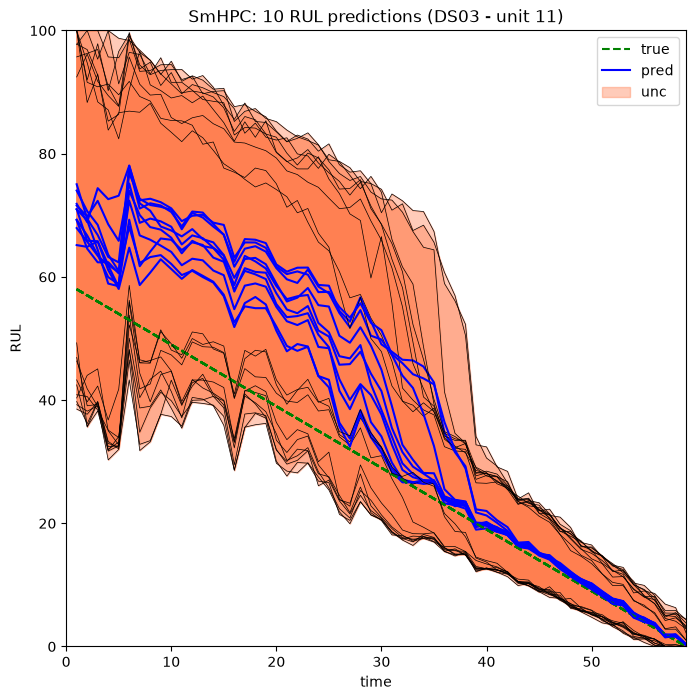

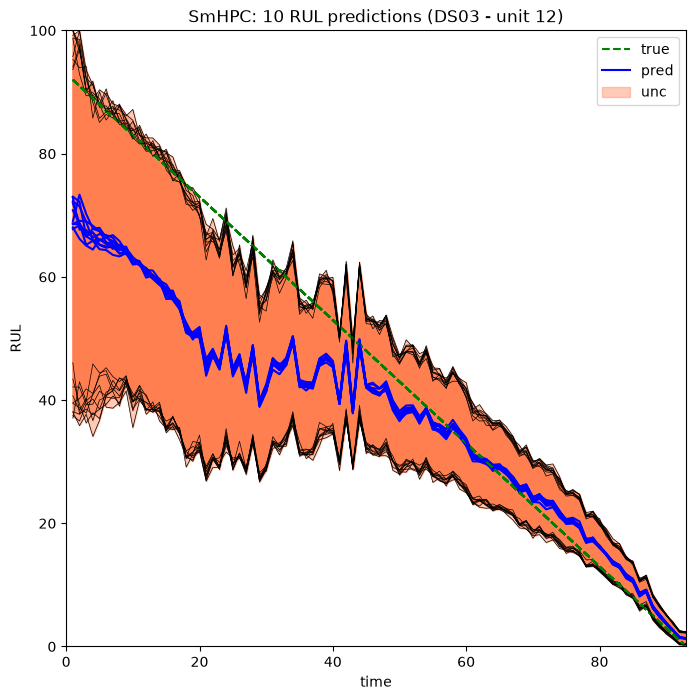

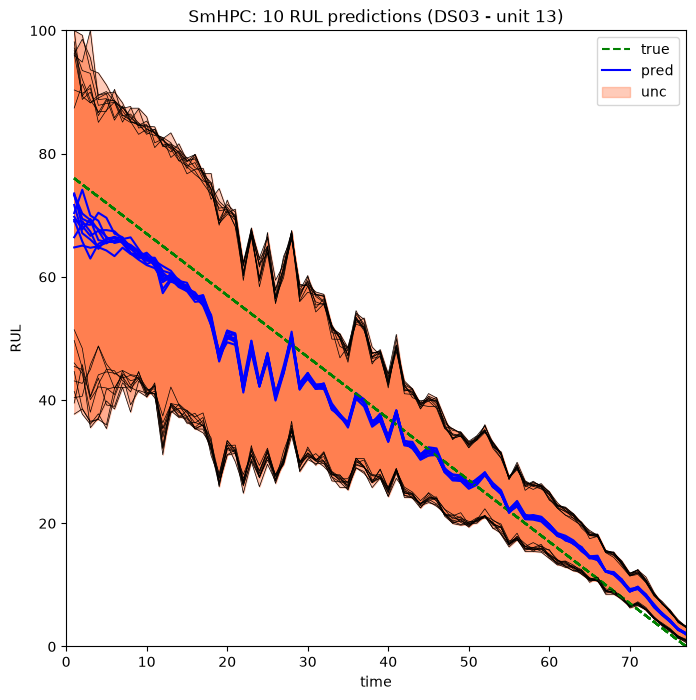

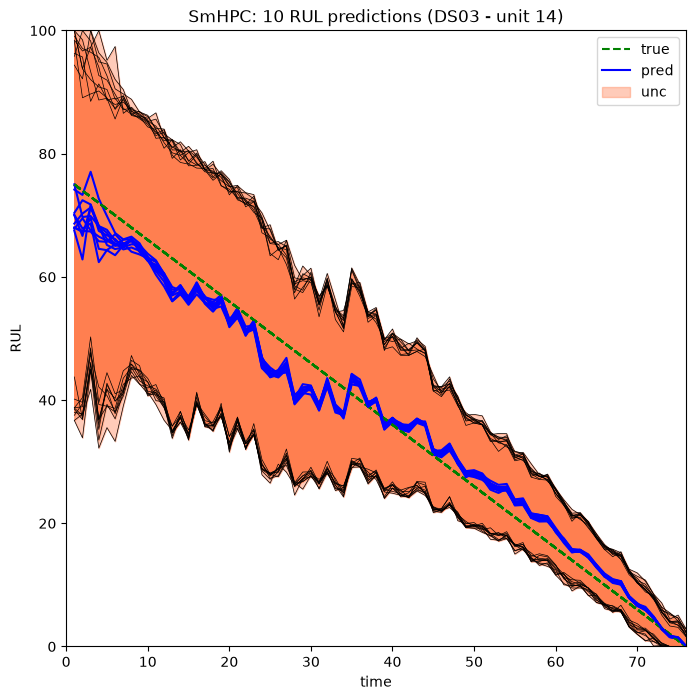

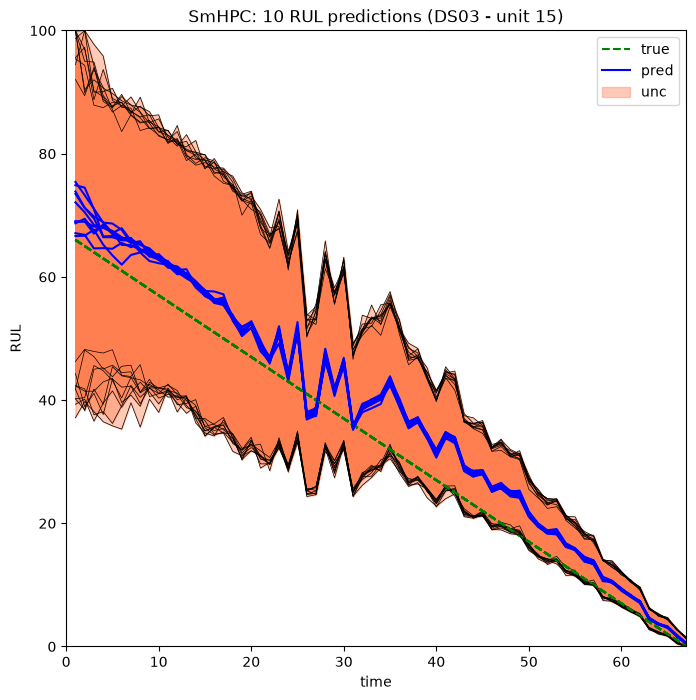

In [17]:
for name in perform_names:
    for unit in test_units:
        sub = df_preds[(df_preds["perform"] == name) & (df_preds["unit"] == unit)]
        if sub.empty:
            continue
        fig, ax = plt.subplots(figsize=(8, 8))
        for i, rep in enumerate(sorted(sub["rep"].unique())):
            df = sub[sub["rep"] == rep]
            eol_time = df["time"].iloc[-1]
            plot_rul_from_dataframe(
                ax=ax,
                df=df,
                t_max=eol_time,
                title=f"{name}: {n_reps} RUL predictions ({DATA_NAME} - unit {unit})",
                show_legend=(i == 0),
            )
        ax.legend(loc="upper right")
        fig.savefig(PFNET_ARGS_DIR / name / f"perform_unit{unit}.png")

## Mean RUL prediction over repetitions

/tmp/ipykernel_3225503/3864247386.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 8))


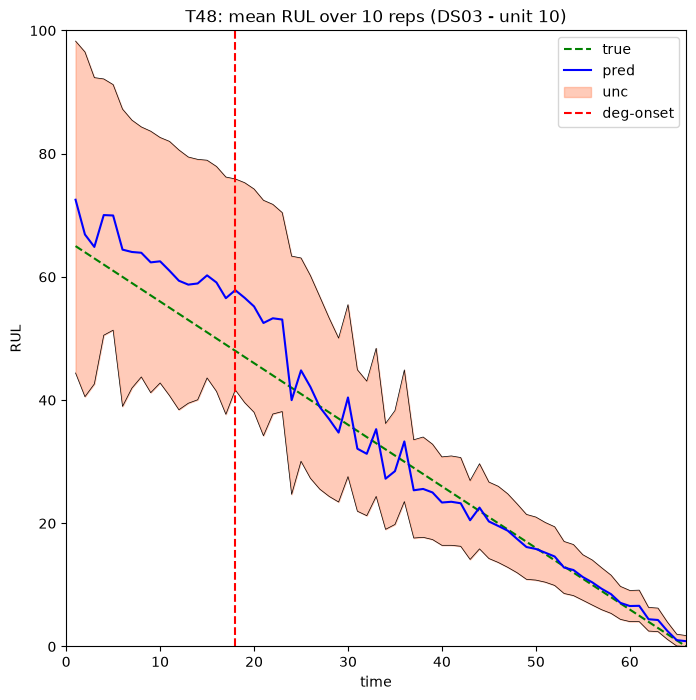

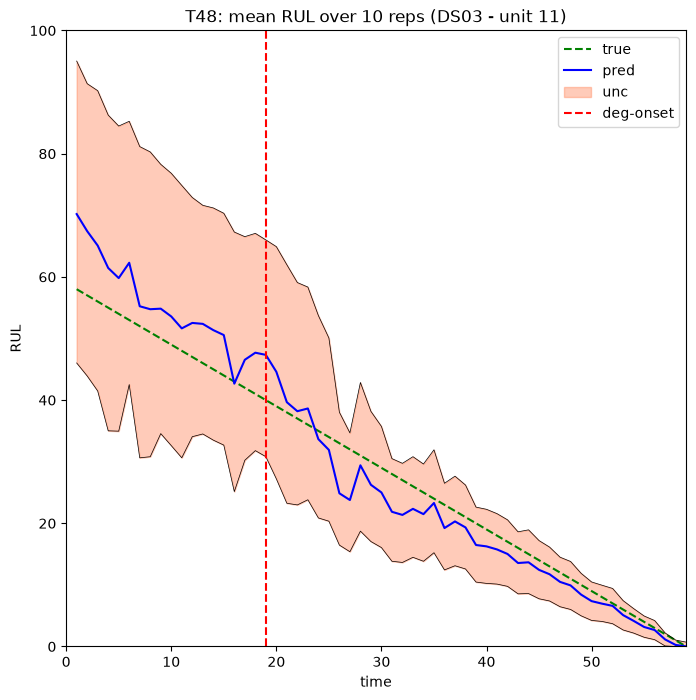

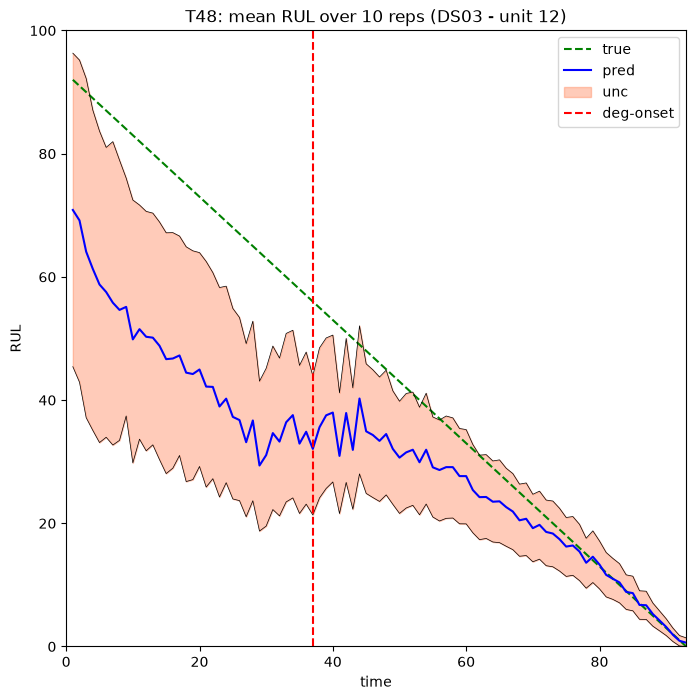

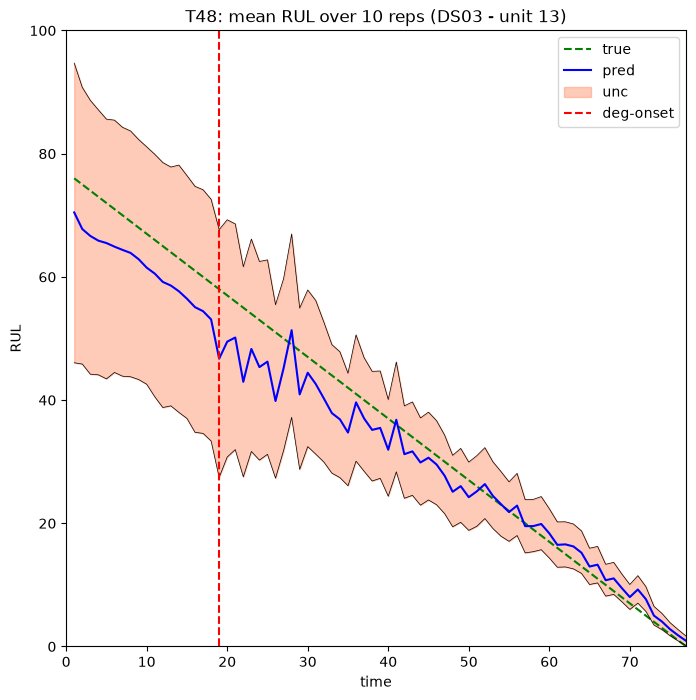

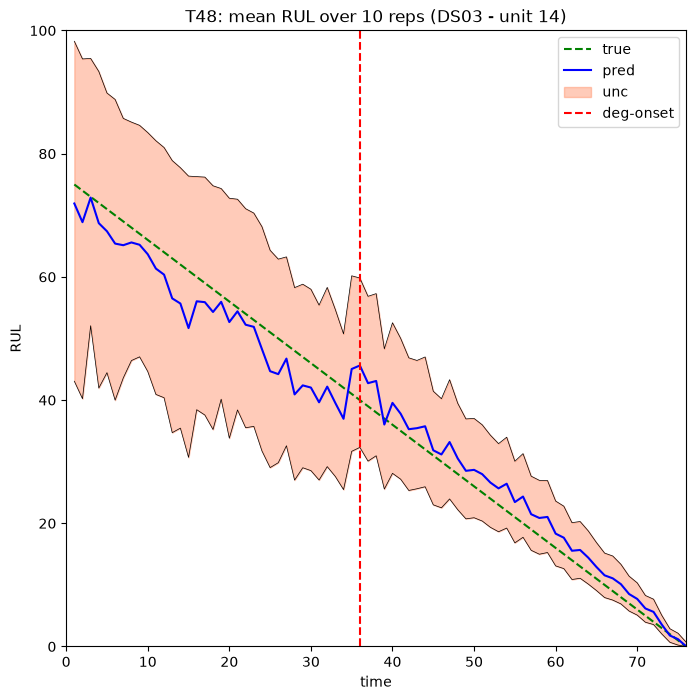

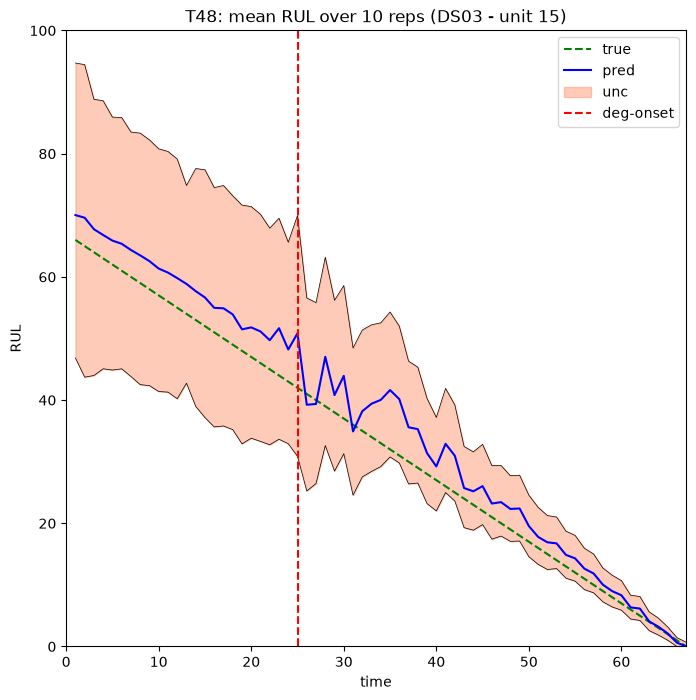

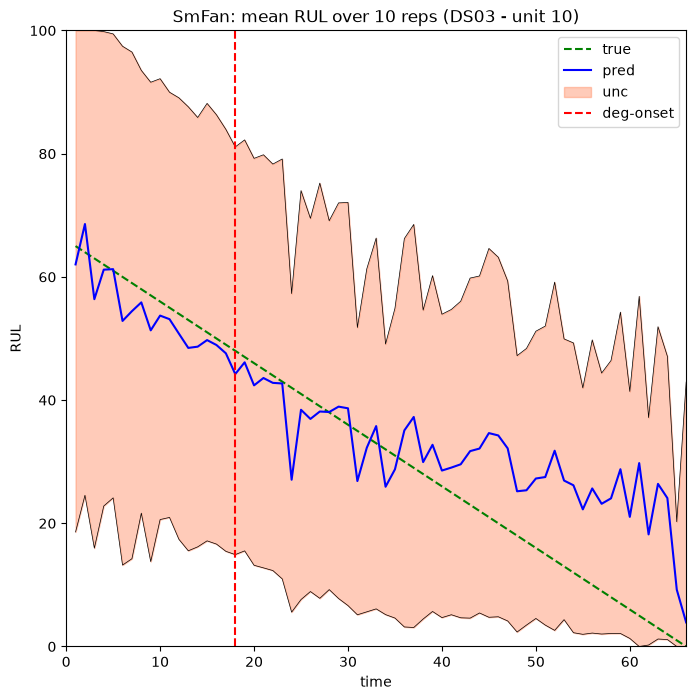

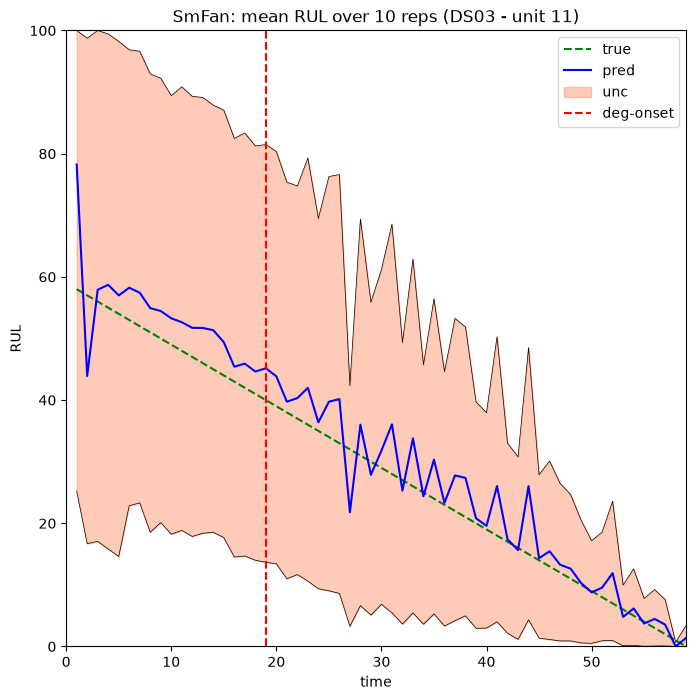

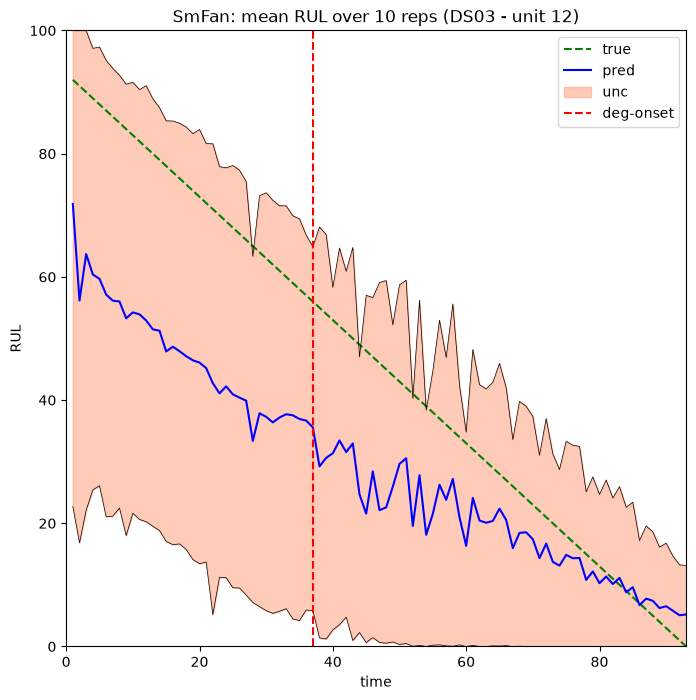

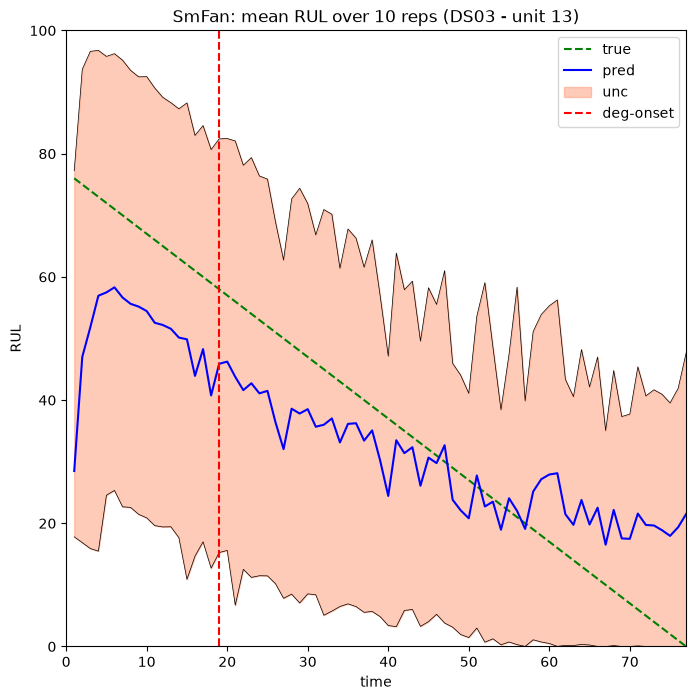

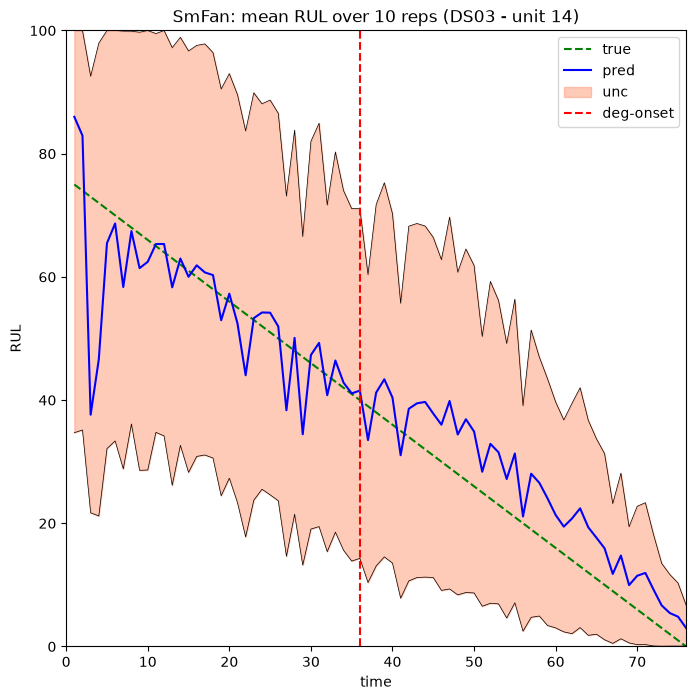

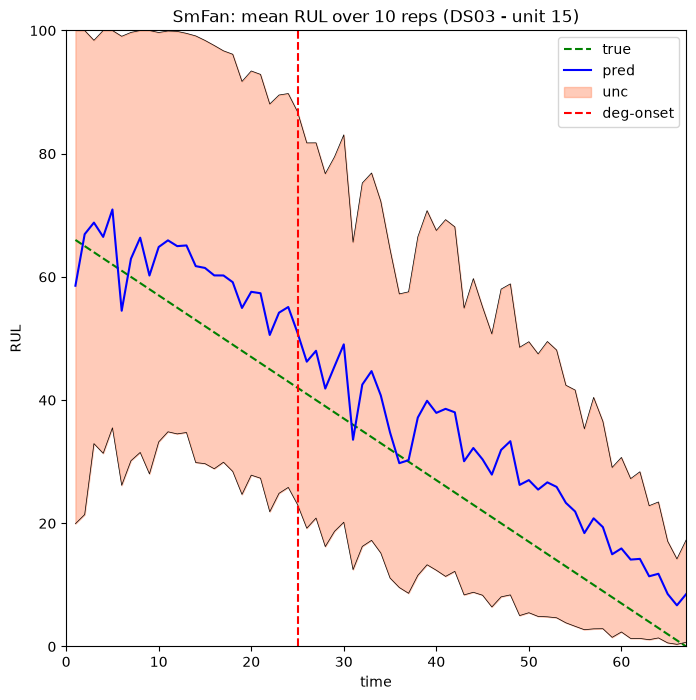

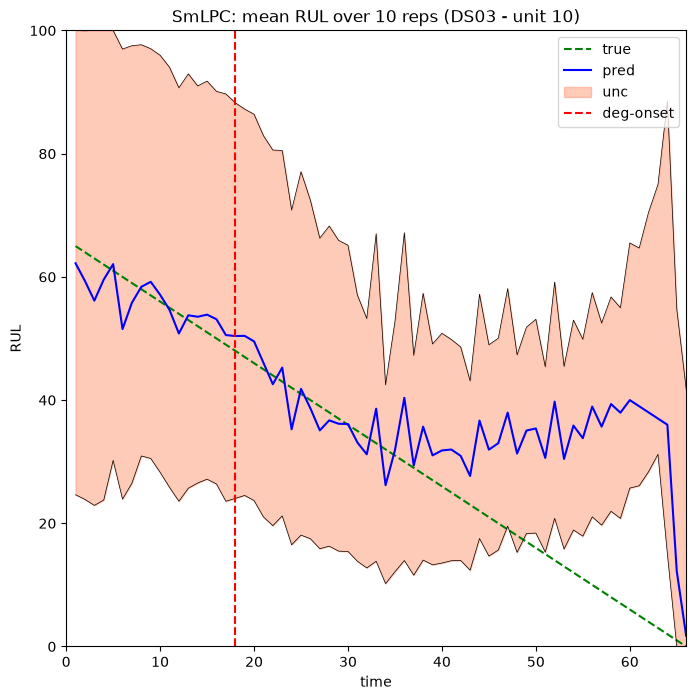

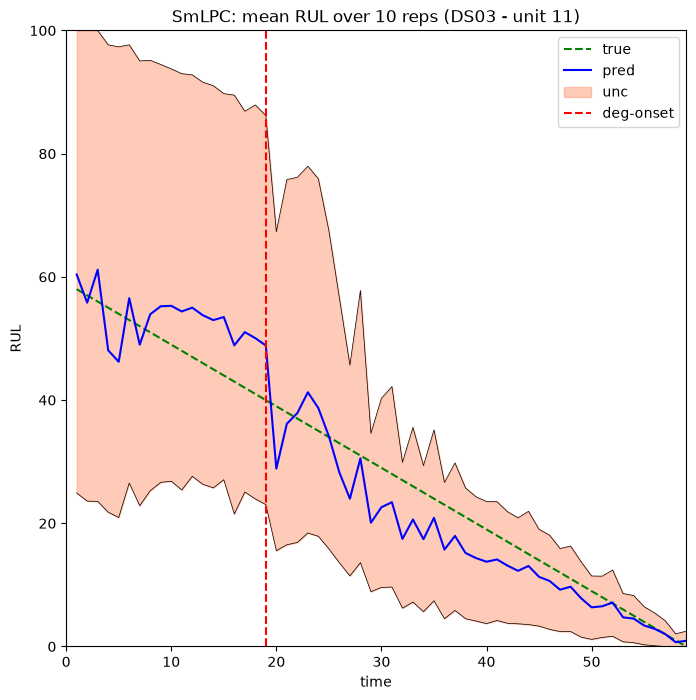

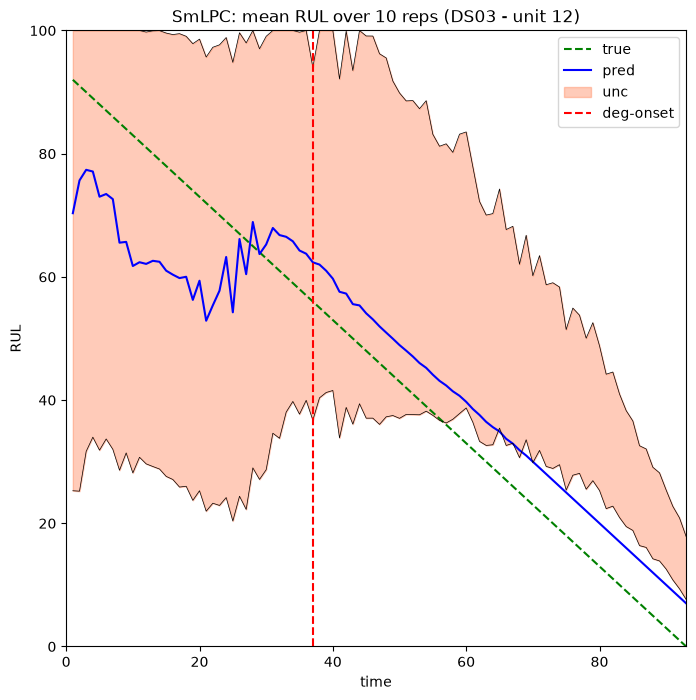

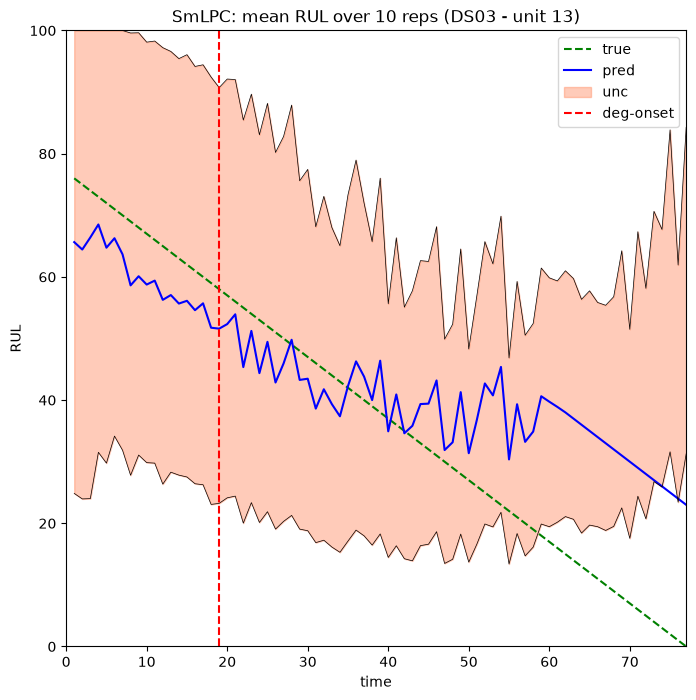

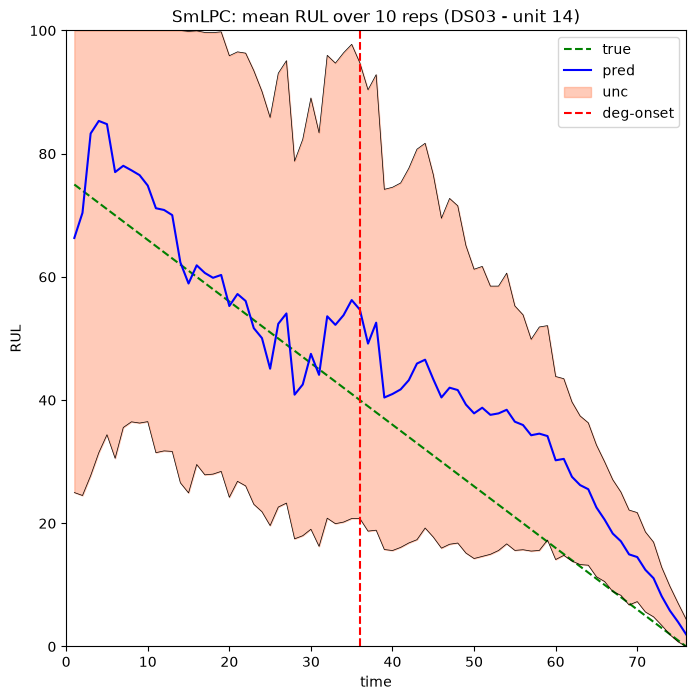

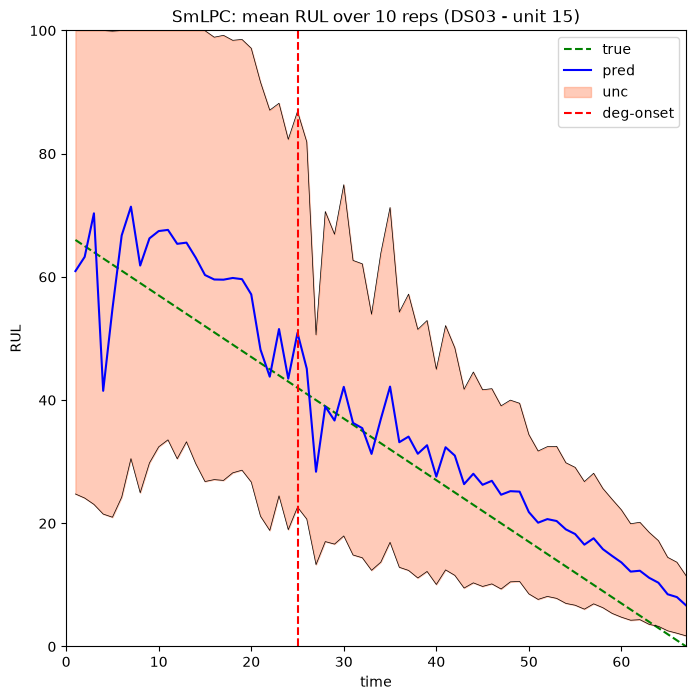

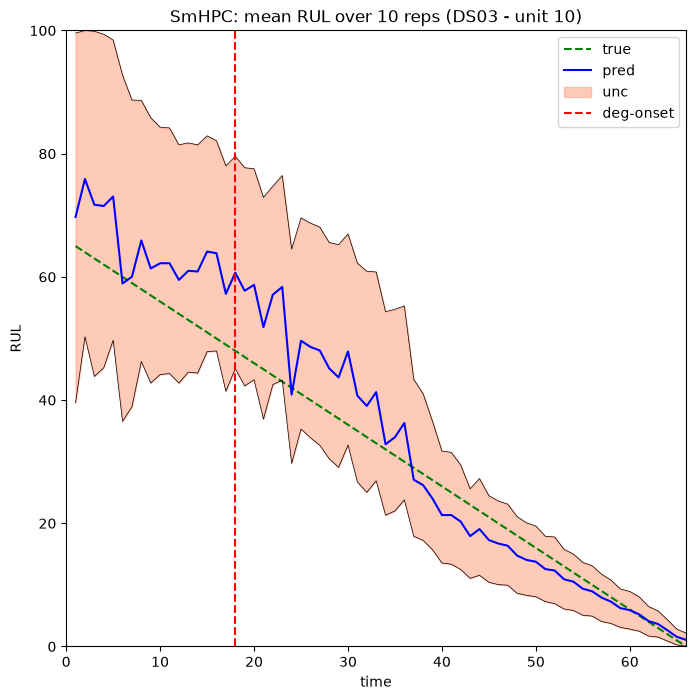

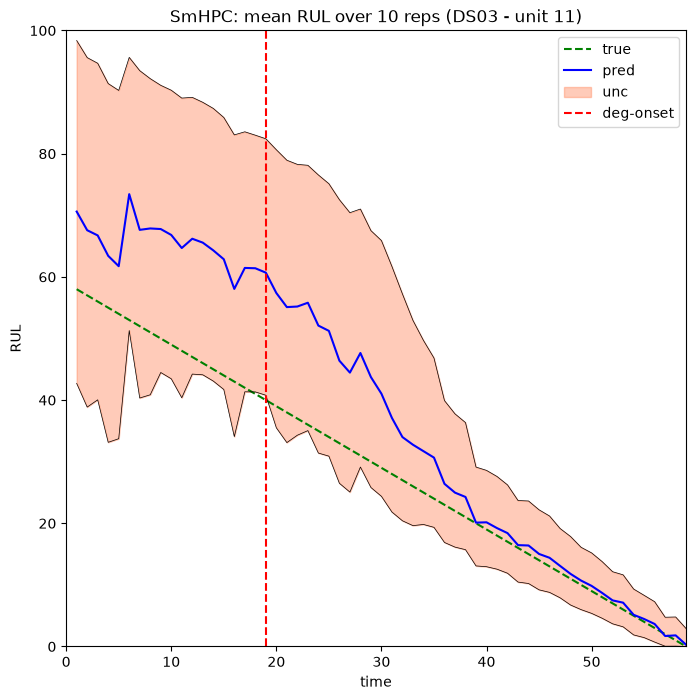

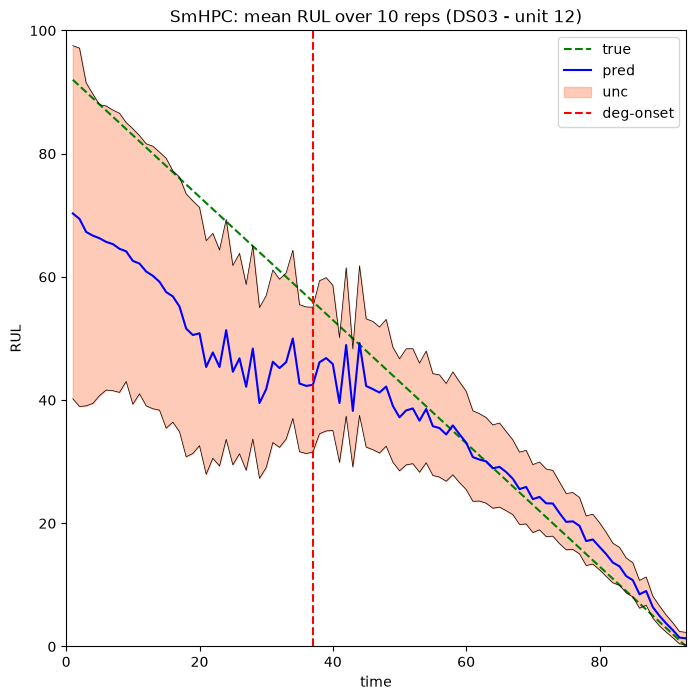

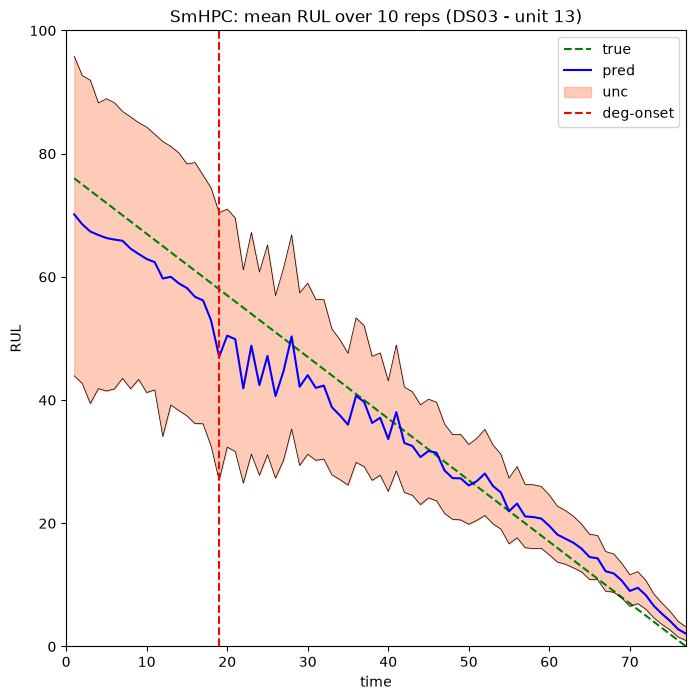

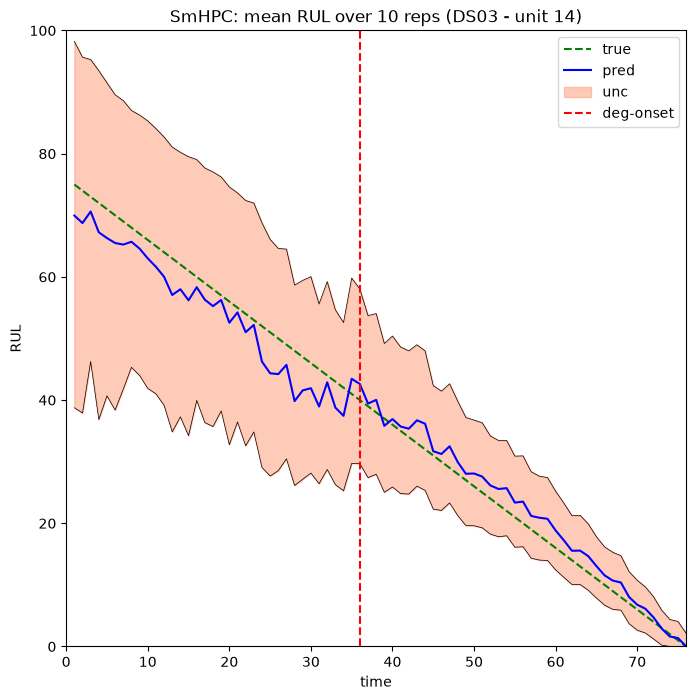

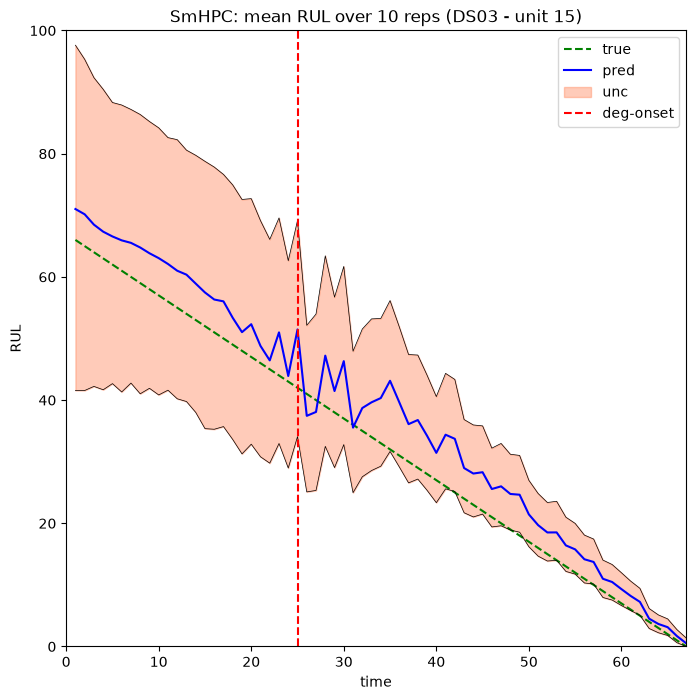

In [18]:
mean_df = df_preds.groupby(["perform", "unit", "time"], as_index=False).mean(
    numeric_only=True
)
for name in perform_names:
    for unit in test_units:
        df = mean_df[(mean_df["perform"] == name) & (mean_df["unit"] == unit)]
        if df.empty:
            continue
        fig, ax = plt.subplots(figsize=(8, 8))
        eol_time = df["time"].iloc[-1]
        plot_rul_from_dataframe(
            ax=ax,
            df=df,
            t_max=eol_time,
            title=f"{name}: mean RUL over {n_reps} reps ({DATA_NAME} - unit {unit})",
            show_legend=True,
        )
        ax.vlines(
            onsets[unit],
            ymin=0,
            ymax=100,
            colors="red",
            linestyles="dashed",
            label="deg-onset",
        )
        ax.legend(loc="upper right")
        fig.savefig(PFNET_ARGS_DIR / name / f"perform_unit{unit}_mean.png")